# Problem Statement
In a competitive market like the restaurant industry, understanding the factors that influence business success is crucial for stakeholders. Utilizing the Yelp dataset, this project aims to investigate the relationship between user engagement (reviews, tips, and check-ins) and business success metrics (review counts, ratings) for restaurants.

# Research Objectives
1. **Quantify the correlation between user engagement (reviews, tips, check-ins) and review count/average star rating:** This will help us determine if restaurants with higher user engagement experience a corresponding increase in reviews and ratings.

2. **Analyze the impact of sentiment on review count and average star rating:** We will investigate if positive sentiment in reviews and tips translates to higher star ratings and potentially influences the total number of reviews left.

3. **Time trends in User Engagement:** We will explore if consistent user engagement over time is stronger indicator of long-term success compared to specific bursts of activity.

4. **The "Rant" Factor (Tip Length vs. Rating):** To determine if there is a statistically significant correlation between a restaurant's overall quality (measured by its average Star Rating) and customer verbosity (measured by the average character length of the tips they leave).

5. **The Weekend vs. Weekday Phenomenon:** To analyze temporal patterns in user physical engagement (check-ins) to verify if weekend engagement drives disproportionately higher volume than weekday engagement.

6. **The "Elite" Influence:** To assess whether the "Elite" status of a user corresponds to a higher perceived value of their reviews by the broader community.

# Hypothesis Testing
- Higher levels of user engagement (more reviews, tips, and check-ins) correlate with higher review counts and ratings for restaurants.
- Positive sentiment expressed in reviews and tips contributes to higher overall ratings and review counts for restaurants.
- Consistent engagement over time is positively associated with sustained business success for restaurants.
- (H1) There is a statistically significant correlation between a restaurant's overall star rating and the average length of the tips left by customers, where lower-rated restaurants receive significantly longer tips.
- Are the average number of daily check-ins is equal on weekends (Saturday/Sunday) and weekdays (Monday-Friday).
- Reviews written by Elite users receive the same or more average number of 'Useful' votes as reviews written by non-Elite users.


## Importing libraries

In [3]:
!pip install folium

In [4]:
!pip install geopy seaborn

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np
import sqlite3
import folium
from scipy import stats
from geopy.geocoders import Nominatim
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

## Database Connection

In [7]:
conn = sqlite3.connect('yelp.db')

In [8]:
tables = pd.read_sql_query("Select name from sqlite_master where type = 'table'", conn)

In [9]:
tables

,name
0,business
1,checkin
2,tip
3,review
4,user


In [10]:
# check the types of data

for table in tables['name']:
    display(pd.read_sql_query(f"Select * from {table} limit 5", conn))

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,categories
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,"Doctors, Traditional Chinese Medicine, Naturop..."
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,"Shipping Centers, Local Services, Notaries, Ma..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"Department Stores, Shopping, Fashion, Home & G..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"Brewpubs, Breweries, Food"


,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020..."
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011..."
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22"
3,--7PUidqRWpRSpXebiyxTg,"2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012..."
4,--7jw19RH9JKXgFohspgQw,"2014-04-21 20:42:11, 2014-04-28 21:04:46, 2014..."


,user_id,business_id,text,date,compliment_count
0,AGNUgVwnZUey3gcPCJ76iw,3uLgwr0qeCNMjKenHJwPGQ,Avengers time with the ladies.,2012-05-18 02:17:21.000000,0
1,NBN4MgHP9D3cw--SnauTkA,QoezRbYQncpRqyrLH6Iqjg,They have lots of good deserts and tasty cuban...,2013-02-05 18:35:10.000000,0
2,-copOvldyKh1qr-vzkDEvw,MYoRNLb5chwjQe3c_k37Gg,It's open even when you think it isn't,2013-08-18 00:56:08.000000,0
3,FjMQVZjSqY8syIO-53KFKw,hV-bABTK-glh5wj31ps_Jw,Very decent fried chicken,2017-06-27 23:05:38.000000,0
4,ld0AperBXk1h6UbqmM80zw,_uN0OudeJ3Zl_tf6nxg5ww,Appetizers.. platter special for lunch,2012-10-06 19:43:09.000000,0


,review_id,user_id,business_id,stars,useful,funny,cool,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,2018-07-07 22:09:11.000000
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,2012-01-03 15:28:18.000000
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,2014-02-05 20:30:30.000000
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,2015-01-04 00:01:03.000000
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,2017-01-14 20:54:15.000000


,user_id,name,review_count,yelping_since,useful,funny,cool,elite,fans,average_stars,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,267,3.91,...,65,55,56,18,232,844,467,467,239,180
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...",3138,3.74,...,264,184,157,251,1847,7054,3131,3131,1521,1946
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013",52,3.32,...,13,10,17,3,66,96,119,119,35,18
3,SZDeASXq7o05mMNLshsdIA,Gwen,224,2005-11-29 04:38:33,512,330,299,"2009,2010,2011",28,4.27,...,4,1,6,2,12,16,26,26,10,9
4,hA5lMy-EnncsH4JoR-hFGQ,Karen,79,2007-01-05 19:40:59,29,15,7,,1,3.54,...,1,0,0,0,1,1,0,0,0,0


## Data Analysis

In [12]:
pd.read_sql_query("Select count(*) from business", conn)

,count(*)
0,150346


In [13]:
business_id = pd.read_sql_query("""select business_id, review_count from business where lower(categories) like '%restaurant%' and is_open = 1""", conn)

In [14]:
# Descriptive stats for review count and star rating for business?
# avg, min, max, median

# The updated query with star metrics added
query = """
SELECT 
    AVG(review_count) AS avg_review_count, 
    MIN(review_count) AS min_review_count, 
    MAX(review_count) AS max_review_count,
    (SELECT review_count FROM business ORDER BY review_count LIMIT 1 OFFSET (SELECT COUNT(*) FROM business) / 2) AS median_review_count,
    
    AVG(stars) AS avg_stars,
    MIN(stars) AS min_stars,
    MAX(stars) AS max_stars,
    (SELECT stars FROM business ORDER BY stars LIMIT 1 OFFSET (SELECT COUNT(*) FROM business) / 2) AS median_stars
    
FROM business 
WHERE business_id IN {}
""".format(tuple(business_id['business_id'])) 

# Execute the query and display the result
stats_df = pd.read_sql_query(query, conn).transpose()
display(stats_df)

,0
avg_review_count,104.097789
min_review_count,5.000000
max_review_count,7568.000000
median_review_count,15.000000
avg_stars,3.523969
min_stars,1.000000
max_stars,5.000000
median_stars,3.500000


The above median and max review count direcly shows that there is outliers in data


In [16]:
# Outliers handling

def remove_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

In [17]:
business_id = remove_outliers(business_id, 'review_count')

In [18]:
business_id.shape

(31537, 2)

In [19]:
# Descriptive stats for review count and star rating for business?
# avg, min, max, median

# The updated query with star metrics added
query = """
SELECT 
    AVG(review_count) AS avg_review_count, 
    MIN(review_count) AS min_review_count, 
    MAX(review_count) AS max_review_count,
    (SELECT review_count FROM business ORDER BY review_count LIMIT 1 OFFSET (SELECT COUNT(*) FROM business) / 2) AS median_review_count,
    
    AVG(stars) AS avg_stars,
    MIN(stars) AS min_stars,
    MAX(stars) AS max_stars,
    (SELECT stars FROM business ORDER BY stars LIMIT 1 OFFSET (SELECT COUNT(*) FROM business) / 2) AS median_stars
    
FROM business 
WHERE business_id IN {}
""".format(tuple(business_id['business_id'])) 

# Execute the query and display the result
stats_df = pd.read_sql_query(query, conn).transpose()
display(stats_df)

,0
avg_review_count,55.975426
min_review_count,5.000000
max_review_count,248.000000
median_review_count,15.000000
avg_stars,3.477281
min_stars,1.000000
max_stars,5.000000
median_stars,3.500000


In [20]:
# Which restaurants have the highest number of reviews?

pd.read_sql_query(f"""select name, sum(review_count) as review_count, avg(stars) as avg_rating
from business
where business_id in {tuple(business_id['business_id'])}
group by name
order by review_count desc
limit 10""", conn)

,name,review_count,avg_rating
0,McDonald's,16490,1.868702
1,Chipotle Mexican Grill,9071,2.381757
2,Taco Bell,8017,2.141813
3,Chick-fil-A,7687,3.377419
4,First Watch,6761,3.875000
5,Panera Bread,6613,2.661905
6,Buffalo Wild Wings,6483,2.344828
7,Domino's Pizza,6091,2.290210
8,Wendy's,5930,2.030159
9,Chili's,5744,2.514706


In [21]:
# Which restaurants have the highest ratings?

pd.read_sql_query(f"""select name, sum(review_count) as review_count, avg(stars) as avg_rating
from business
where business_id in {tuple(business_id['business_id'])}
group by name
order by avg_rating desc
limit 10""", conn)

,name,review_count,avg_rating
0,ā café,48,5.0
1,two birds cafe,77,5.0
2,the brewers cabinet production,13,5.0
3,taqueria la cañada,17,5.0
4,la bamba,44,5.0
5,la 5th av tacos,24,5.0
6,el sabor mexican and chinese food,21,5.0
7,eat.drink.Om...YOGA CAFE,7,5.0
8,d4 Tabletop Gaming Cafe,8,5.0
9,cabbage vegetarian cafe,12,5.0


In [22]:
# Do restaurants with higher engagement tend to have higher ratings?

pd.read_sql_query("""select business_id,
sum(length(date) - length(replace(date,',',''))+1) as checkin_count
from checkin
group by business_id""", conn)


,business_id,checkin_count
0,---kPU91CF4Lq2-WlRu9Lw,11
1,--0iUa4sNDFiZFrAdIWhZQ,10
2,--30_8IhuyMHbSOcNWd6DQ,2
3,--7PUidqRWpRSpXebiyxTg,10
4,--7jw19RH9JKXgFohspgQw,26
...,...,...
131925,zznJox6-nmXlGYNWgTDwQQ,67
131926,zznZqH9CiAznbkV6fXyHWA,1
131927,zzu6_r3DxBJuXcjnOYVdTw,23
131928,zzw66H6hVjXQEt0Js3Mo4A,2


In [23]:
# Tip table
pd.read_sql_query("""select business_id, count(*) as tip_count
from tip
group by business_id""", conn)


,business_id,tip_count
0,---kPU91CF4Lq2-WlRu9Lw,4
1,--0iUa4sNDFiZFrAdIWhZQ,6
2,--30_8IhuyMHbSOcNWd6DQ,1
3,--7PUidqRWpRSpXebiyxTg,3
4,--8IbOsAAxjKRoYsBFL-PA,4
...,...,...
106188,zzjCxn89a7RQo8keIOO_Ag,1
106189,zzjFdJwXuxBOGe9JeY_EMw,2
106190,zznJox6-nmXlGYNWgTDwQQ,6
106191,zzu6_r3DxBJuXcjnOYVdTw,2


In [41]:
# Do restaurants with higher engagement tend to have higher ratings?

query = """
WITH TargetBusinesses AS (
    -- Step 1: Get the base restaurants and their star ratings
    SELECT business_id, stars AS rating, review_count
    FROM business
    WHERE business_id IN {}
),
TipCounts AS (
    -- Step 2: Count the total tips per business
    SELECT business_id, COUNT(*) AS tip_count
    FROM tip
    GROUP BY business_id
),
CheckinCounts AS (
    -- Step 3: Count the total check-ins using your comma-counting logic
    SELECT business_id, 
           (LENGTH(date) - LENGTH(REPLACE(date, ',', '')) + 1) AS checkin_count
    FROM checkin
),
CombinedMetrics AS (
    -- Step 4: Join them all together. 
    -- COALESCE ensures that if a restaurant has no tips/checkins, it counts as 0 instead of NULL
    SELECT 
        b.business_id,
        b.rating,
        b.review_count,
        COALESCE(t.tip_count, 0) AS tip_count,
        COALESCE(c.checkin_count, 0) AS checkin_count
    FROM TargetBusinesses b
    LEFT JOIN TipCounts t ON b.business_id = t.business_id
    LEFT JOIN CheckinCounts c ON b.business_id = c.business_id
)

-- Step 5: Calculate the final averages grouped by the star rating
SELECT 
    rating,
    AVG(review_count) AS avg_review_count,
    AVG(checkin_count) AS avg_checkin_count,
    AVG(tip_count) AS avg_tip_count
FROM CombinedMetrics
GROUP BY rating
""".format(tuple(business_id['business_id']))

# Execute the query and display the final aggregated table
engagement_df = pd.read_sql_query(query, conn)
display(engagement_df)

,rating,avg_review_count,avg_checkin_count,avg_tip_count
0,1.0,14.365079,15.386243,1.751323
1,1.5,24.358459,33.383585,3.243719
2,2.0,27.759629,51.195360,3.815777
3,2.5,36.631037,78.301996,5.441404
4,3.0,48.054998,104.591967,7.384984
5,3.5,63.730125,124.643234,9.512747
6,4.0,73.136954,125.926623,10.328477
7,4.5,65.282554,85.116753,7.931141
8,5.0,31.127979,25.867608,2.912621


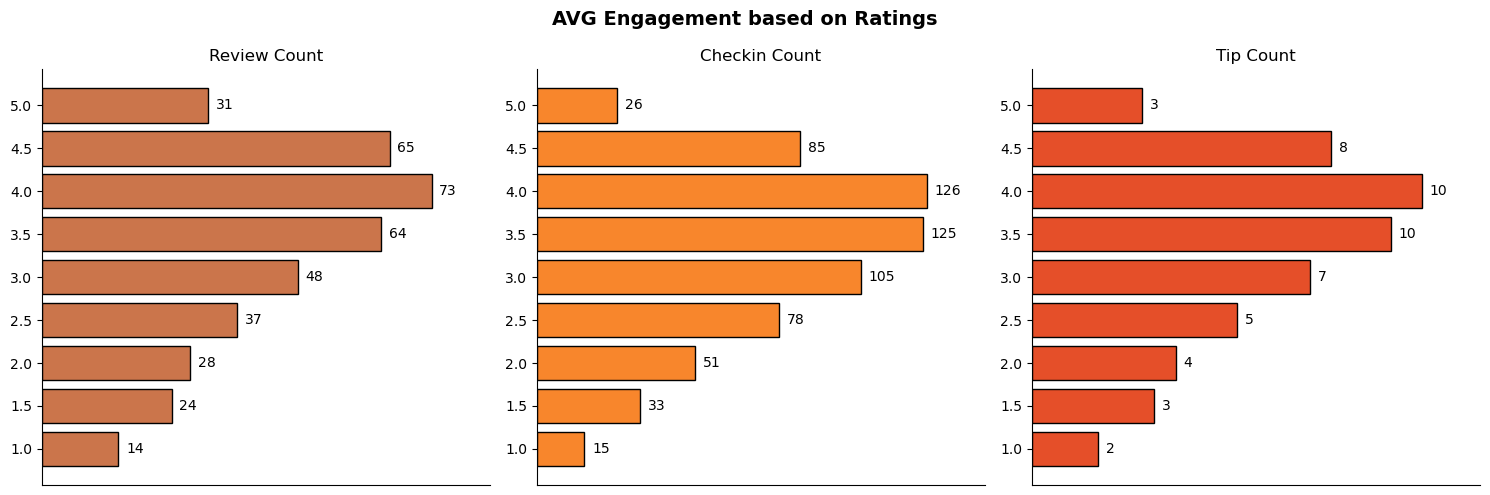

In [43]:
plt.figure(figsize=(15,5))
# Using suptitle centers the main title over all three subplots
plt.suptitle("AVG Engagement based on Ratings", fontsize=14, fontweight='bold')

# --- Subplot 1: Review Count ---
plt.subplot(1,3,1)
plt.title('Review Count')
plt.barh(engagement_df['rating'].astype('str'), engagement_df['avg_review_count'], edgecolor='k', color='#CB754B')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

# Add 15% extra space to the right of the longest bar for the text
max_review = engagement_df['avg_review_count'].max()
plt.xlim(0, max_review * 1.15) 

for i, value in enumerate(engagement_df['avg_review_count']):
    plt.text(value + (max_review * 0.02), i, str(round(value)), color='black', va='center')
plt.xticks([])


# --- Subplot 2: Checkin Count ---
plt.subplot(1,3,2)
plt.title('Checkin Count')
plt.barh(engagement_df['rating'].astype('str'), engagement_df['avg_checkin_count'], edgecolor='k', color='#F8862C')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

max_checkin = engagement_df['avg_checkin_count'].max()
plt.xlim(0, max_checkin * 1.15)

for i, value in enumerate(engagement_df['avg_checkin_count']):
    plt.text(value + (max_checkin * 0.02), i, str(round(value)), color='black', va='center')
plt.xticks([])


# --- Subplot 3: Tip Count ---
plt.subplot(1,3,3)
plt.title('Tip Count')
plt.barh(engagement_df['rating'].astype('str'), engagement_df['avg_tip_count'], edgecolor='k', color='#E54F29')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

# This prevents your '10' from getting cut off on the right side!
max_tip = engagement_df['avg_tip_count'].max()
plt.xlim(0, max_tip * 1.15)

for i, value in enumerate(engagement_df['avg_tip_count']):
    plt.text(value + (max_tip * 0.02), i, str(round(value)), color='black', va='center')
plt.xticks([])

# Keep it clean
plt.tight_layout()
plt.show()

In [45]:
# Is there a correlation between the number of reviews, tips, and check-ins for a business?

query = """
WITH TargetBusinesses AS (
    -- Step 1: Grab the base stats for your specific restaurants
    SELECT business_id, review_count, stars AS avg_rating
    FROM business
    WHERE business_id IN {}
),
TipCounts AS (
    -- Step 2: Count the tips per business
    SELECT business_id, COUNT(business_id) AS tip_count
    FROM tip
    GROUP BY business_id
    order by tip_count
),
CheckinCounts AS (
    -- Step 3: Count the check-ins (using her exact SUM and LENGTH logic)
    SELECT business_id, 
           SUM(LENGTH(date) - LENGTH(REPLACE(date, ',', '')) + 1) AS checkin_count
    FROM checkin
    GROUP BY business_id
)

-- Step 4: Bring it all together cleanly without needing a massive GROUP BY
SELECT 
    b.business_id,
    b.review_count,
    b.avg_rating,
    c.checkin_count,
    t.tip_count
FROM TargetBusinesses b
LEFT JOIN CheckinCounts c ON b.business_id = c.business_id
LEFT JOIN TipCounts t ON b.business_id = t.business_id
""".format(tuple(business_id['business_id']))

# Execute the query and apply the tutor's exact .dropna() method
correlation_df = pd.read_sql_query(query, conn).dropna()

# Display the clean dataset ready for correlation
display(correlation_df)

,business_id,review_count,avg_rating,checkin_count,tip_count
0,MTSW4McQd7CbVtyjqoe9mw,80,4.0,335.0,10.0
1,CF33F8-E6oudUQ46HnavjQ,6,2.0,22.0,2.0
2,bBDDEgkFA1Otx9Lfe7BZUQ,10,1.5,21.0,2.0
3,eEOYSgkmpB90uNA7lDOMRA,10,4.0,4.0,1.0
4,il_Ro8jwPlHresjw9EGmBg,28,2.5,54.0,5.0
...,...,...,...,...,...
31532,sf_oQ62L8UEnOOLf00nNGA,6,3.0,8.0,1.0
31533,l9eLGG9ZKpLJzboZq-9LRQ,11,3.0,106.0,5.0
31534,cM6V90ExQD6KMSU3rRB5ZA,33,4.0,199.0,9.0
31535,WnT9NIzQgLlILjPT0kEcsQ,35,4.5,28.0,4.0


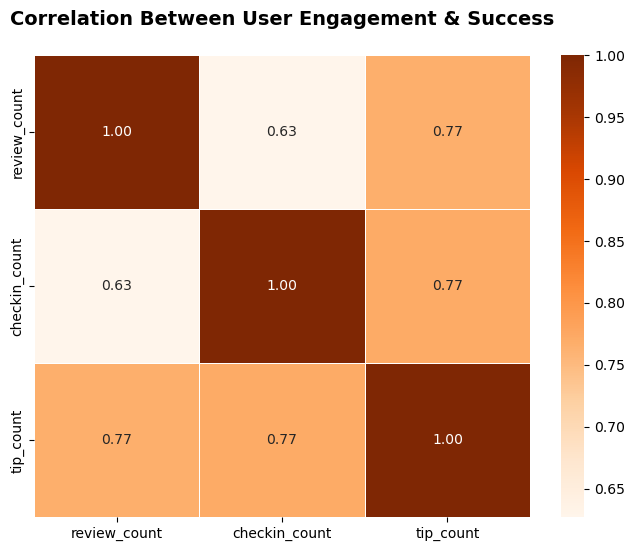

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select only the numerical columns for correlation
metrics_to_correlate = ['review_count', 'checkin_count', 'tip_count']

# 2. Calculate the correlation matrix
corr_matrix = correlation_df[metrics_to_correlate].corr()

# 3. Build the Heatmap Visualization
plt.figure(figsize=(8, 6))
plt.title('Correlation Between User Engagement & Success\n', fontsize=14, fontweight='bold')

# annot=True shows the exact decimal numbers inside the colored boxes
sns.heatmap(corr_matrix, annot=True, cmap='Oranges', fmt='.2f', linewidths=0.5)

plt.show()

In [49]:
# Is there any difference in the user engagement (reviews, tips, and check-ins) between high-rated and low-rated business?

query = """
WITH TargetBusinesses AS (
    SELECT business_id, review_count, stars AS avg_rating
    FROM business
    WHERE business_id IN {}
),
TipCounts AS (
    -- Step 2: Count the tips per business
    SELECT business_id, COUNT(business_id) AS tip_count
    FROM tip
    GROUP BY business_id
    order by tip_count
),
CheckinCounts AS (
    -- Step 3: Count the check-ins (using her exact SUM and LENGTH logic)
    SELECT business_id, 
           SUM(LENGTH(date) - LENGTH(REPLACE(date, ',', '')) + 1) AS checkin_count
    FROM checkin
    GROUP BY business_id
)

-- Step 4: Bring it all together cleanly without needing a massive GROUP BY
SELECT 
    b.business_id,
    b.review_count,
    b.avg_rating,
    c.checkin_count,
    t.tip_count,
    (case when b.avg_rating >= 3.5 then 'High-Rated' else 'Low-Rated' end) as category
FROM TargetBusinesses b
LEFT JOIN CheckinCounts c ON b.business_id = c.business_id
LEFT JOIN TipCounts t ON b.business_id = t.business_id
""".format(tuple(business_id['business_id']))

# Execute the query and apply the tutor's exact .dropna() method
rating_df = pd.read_sql_query(query, conn).dropna()

# Display the clean dataset ready for correlation
display(rating_df)

,business_id,review_count,avg_rating,checkin_count,tip_count,category
0,MTSW4McQd7CbVtyjqoe9mw,80,4.0,335.0,10.0,High-Rated
1,CF33F8-E6oudUQ46HnavjQ,6,2.0,22.0,2.0,Low-Rated
2,bBDDEgkFA1Otx9Lfe7BZUQ,10,1.5,21.0,2.0,Low-Rated
3,eEOYSgkmpB90uNA7lDOMRA,10,4.0,4.0,1.0,High-Rated
4,il_Ro8jwPlHresjw9EGmBg,28,2.5,54.0,5.0,Low-Rated
...,...,...,...,...,...,...
31532,sf_oQ62L8UEnOOLf00nNGA,6,3.0,8.0,1.0,Low-Rated
31533,l9eLGG9ZKpLJzboZq-9LRQ,11,3.0,106.0,5.0,Low-Rated
31534,cM6V90ExQD6KMSU3rRB5ZA,33,4.0,199.0,9.0,High-Rated
31535,WnT9NIzQgLlILjPT0kEcsQ,35,4.5,28.0,4.0,High-Rated


In [50]:
rating_df.groupby("category")[['review_count', 'tip_count', 'checkin_count']].mean()

,review_count,tip_count,checkin_count
category,,,
High-Rated,72.291062,10.162766,122.066641
Low-Rated,42.123420,6.541689,88.880828


Here we get high engagement for high-rating 

In [51]:
# function to calculate the success score based on the avg rating and total review count
def calculate_success_metric(df):
    success_score = []
    for index, row in df.iterrows():
        score = row['avg_rating'] * np.log(row['review_count'] + 1)
        success_score.append(score)
    return success_score

In [52]:
# How do the success metrics (review_count or avg_rating) of restaurants vary across different states and cities?
city_df = pd.read_sql_query(f"""select city, state, latitude, longitude, avg(stars) as avg_rating, sum(review_count) as review_count,
count(*) as restaurant_count
from business
where business_id in {tuple(business_id['business_id'])}
group by state, city
order by review_count desc
limit 10""", conn)

city_df['success_score'] = calculate_success_metric(city_df)

In [53]:
city_df

,city,state,latitude,longitude,avg_rating,review_count,restaurant_count,success_score
0,Philadelphia,PA,39.955505,-75.155564,3.532156,175487,3001,42.651934
1,Tampa,FL,27.890814,-82.502346,3.571429,104376,1715,41.270588
2,Indianapolis,IN,39.637133,-86.127217,3.412111,92639,1701,39.022521
3,Tucson,AZ,32.338572,-111.010760,3.386187,91613,1419,38.688341
4,Nashville,TN,36.208102,-86.768170,3.493590,87070,1404,39.737764
5,New Orleans,LA,29.963974,-90.042604,3.693676,69239,1012,41.167252
6,Saint Louis,MO,38.583223,-90.407187,3.414303,51490,811,37.042331
7,Reno,NV,39.476518,-119.784037,3.479626,48393,589,37.535187
8,Edmonton,AB,53.436403,-113.604288,3.509379,45916,1546,37.671748
9,Boise,ID,43.611192,-116.206275,3.558824,36104,561,37.346958


In [54]:
# create a base map
m = folium.Map(location=[city_df['latitude'].mean(), city_df['longitude'].mean()], zoom_start=4)

# Define a color scale
color_scale = folium.LinearColormap(colors=['green', 'yellow', '#E54F29'],
                                   vmin=city_df['success_score'].min(),
                                   vmax=city_df['success_score'].max())

# Add markers to the map
for index, row in city_df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        color=color_scale(row['success_score']),
        fill=True,
        fill_color=color_scale(row['success_score']),
        fill_opacity=0.7,
        popup=f"Success Score: {row['success_score']}"
    ).add_to(m)

# Add color scale to the map
m.add_child(color_scale)

In [55]:
high_rated_engagement = pd.read_sql_query(f"""
WITH ReviewTrends AS (
    SELECT 
        strftime('%m-%Y', r.date) AS month_year, 
        COUNT(*) AS review_count
    FROM review r
    JOIN business b ON r.business_id = b.business_id
    WHERE r.business_id IN {tuple(business_id['business_id'])} AND b.stars >= 3.5
    GROUP BY month_year
),
TipTrends AS (
    SELECT 
        strftime('%m-%Y', tip.date) AS month_year, 
        COUNT(*) AS tip_count
    FROM tip
    JOIN business b ON tip.business_id = b.business_id
    WHERE tip.business_id IN {tuple(business_id['business_id'])} AND b.stars >= 3.5
    GROUP BY month_year
)

SELECT 
    r.month_year, 
    r.review_count, 
    t.tip_count 
FROM ReviewTrends r
JOIN TipTrends t ON r.month_year = t.month_year
ORDER BY r.month_year;
""", conn)

low_rated_engagement = pd.read_sql_query(f"""
WITH ReviewTrends AS (
    SELECT 
        strftime('%m-%Y', r.date) AS month_year, 
        COUNT(*) AS review_count
    FROM review r
    JOIN business b ON r.business_id = b.business_id
    WHERE r.business_id IN {tuple(business_id['business_id'])} AND b.stars < 3.5
    GROUP BY month_year
),
TipTrends AS (
    SELECT 
        strftime('%m-%Y', tip.date) AS month_year, 
        COUNT(*) AS tip_count
    FROM tip
    JOIN business b ON tip.business_id = b.business_id
    WHERE tip.business_id IN {tuple(business_id['business_id'])} AND b.stars < 3.5
    GROUP BY month_year
)

SELECT 
    r.month_year, 
    r.review_count, 
    t.tip_count 
FROM ReviewTrends r
JOIN TipTrends t ON r.month_year = t.month_year
ORDER BY r.month_year;
""", conn)

In [56]:
high_rated_engagement

,month_year,review_count,tip_count
0,01-2010,1354,79
1,01-2011,2438,621
2,01-2012,3580,1321
3,01-2013,4324,1230
4,01-2014,5742,1357
...,...,...,...
149,12-2017,12075,1477
150,12-2018,15408,1163
151,12-2019,16599,1161
152,12-2020,13158,937


In [63]:
time_rating = pd.read_sql_query(f"""select strftime('%m-%Y', date) as month_year,
avg(stars) as avg_rating
from review
where business_id in {tuple(business_id['business_id'])}
group by month_year
order by month_year
;""", conn)

In [64]:
time_rating['month_year'] = pd.to_datetime(time_rating['month_year'])
time_rating.sort_values('month_year', inplace=True)
time_rating = time_rating[time_rating['month_year'] > '2017']

high_rated_engagement['month_year'] = pd.to_datetime(high_rated_engagement['month_year'])
high_rated_engagement.sort_values('month_year', inplace=True)
high_rated_engagement = high_rated_engagement[high_rated_engagement['month_year'] > '2017']

low_rated_engagement['month_year'] = pd.to_datetime(low_rated_engagement['month_year'])
low_rated_engagement.sort_values('month_year', inplace=True)
low_rated_engagement = low_rated_engagement[low_rated_engagement['month_year'] > '2017']


In [65]:
high_rated_engagement['avg_rating'] = time_rating['avg_rating'].values

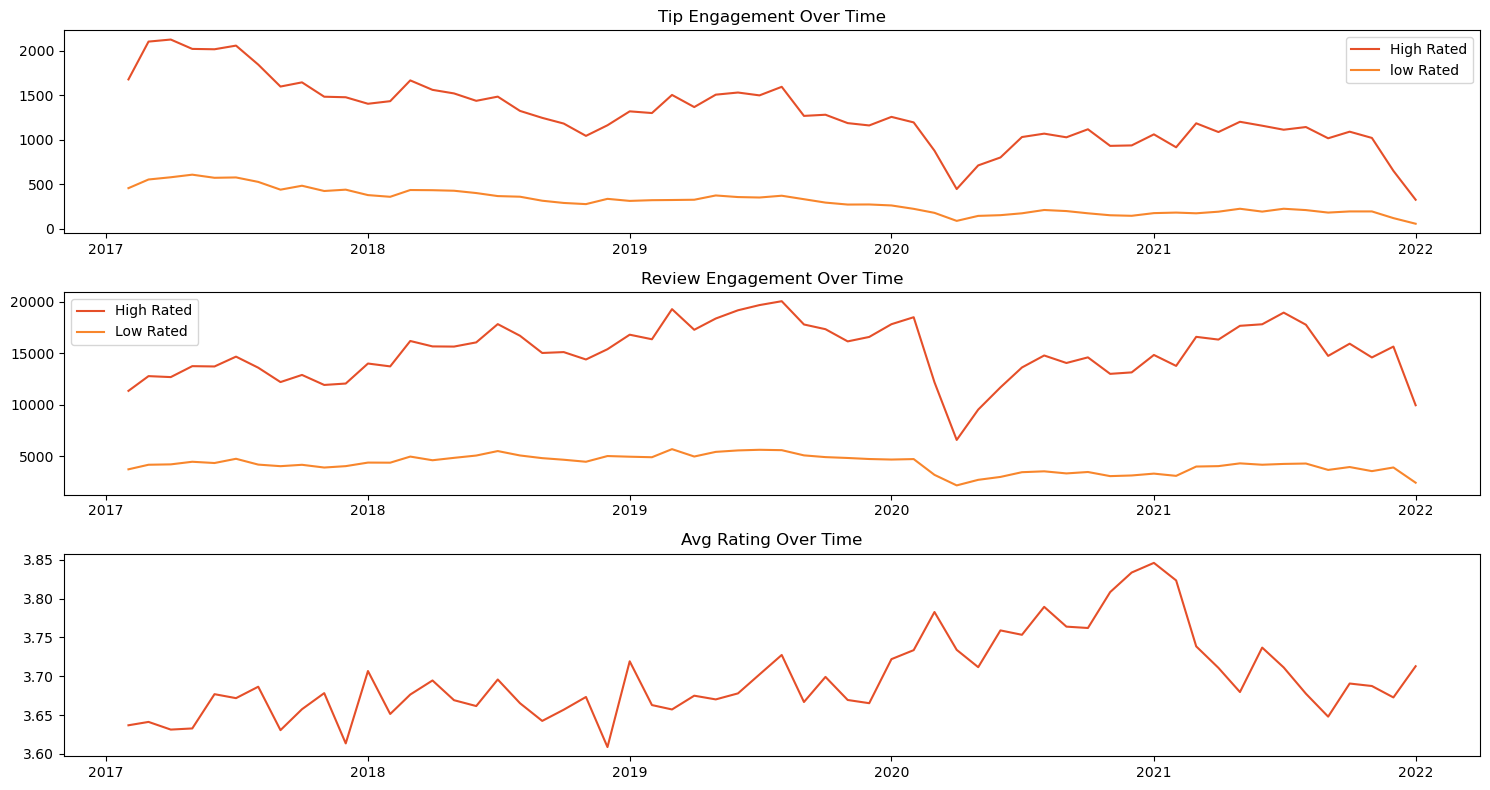

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize = (15,8))

# --- Subplot 1: Tip Engagement ---
plt.subplot(3,1,1)
plt.title('Tip Engagement Over Time')
plt.plot(high_rated_engagement['month_year'], high_rated_engagement['tip_count'], label = 'High Rated', color = '#E54F29')
plt.plot(low_rated_engagement['month_year'], low_rated_engagement['tip_count'], label = 'low Rated', color = '#F8862C')
plt.legend()

# --- Subplot 2: Review Engagement ---
plt.subplot(3,1,2)
plt.title('Review Engagement Over Time')
plt.plot(high_rated_engagement['month_year'], high_rated_engagement['review_count'], label = 'High Rated', color = '#E54F29')
plt.plot(low_rated_engagement['month_year'], low_rated_engagement['review_count'], label = 'Low Rated', color = '#F8862C')
plt.legend()

# --- Subplot 3: Avg Rating Over Time ---
plt.subplot(3,1,3)
plt.title('Avg Rating Over Time')
plt.plot(time_rating['month_year'], time_rating['avg_rating'], color = '#E54F29')

plt.tight_layout()
plt.show()

In [67]:
tip_high_rated = high_rated_engagement[['month_year', 'tip_count']].set_index('month_year')
review_high_rated = high_rated_engagement[['month_year', 'review_count']].set_index('month_year')
rating_df = time_rating[['month_year', 'avg_rating']].set_index('month_year')

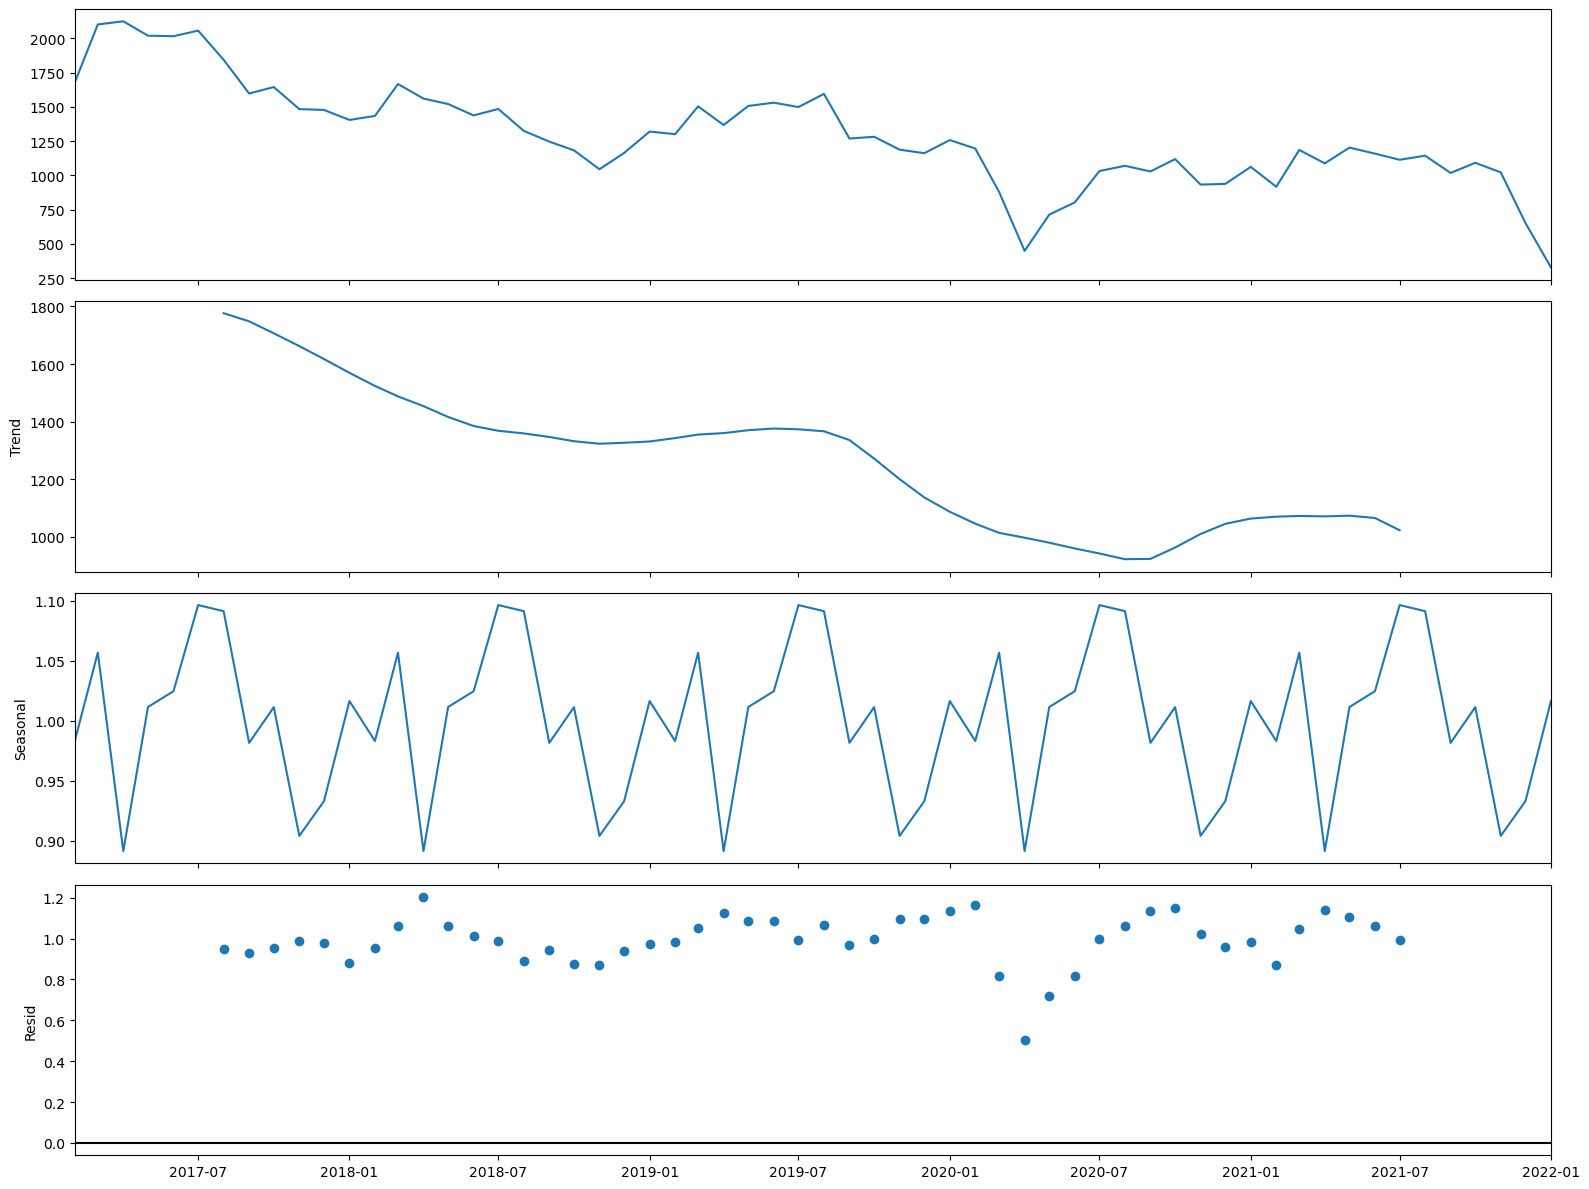

In [68]:
from statsmodels.tsa.seasonal import seasonal_decompose

multiplicative_decomposition = seasonal_decompose(tip_high_rated, 
                                                  model='multiplicative', period = 12)

plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot()
plt.show()

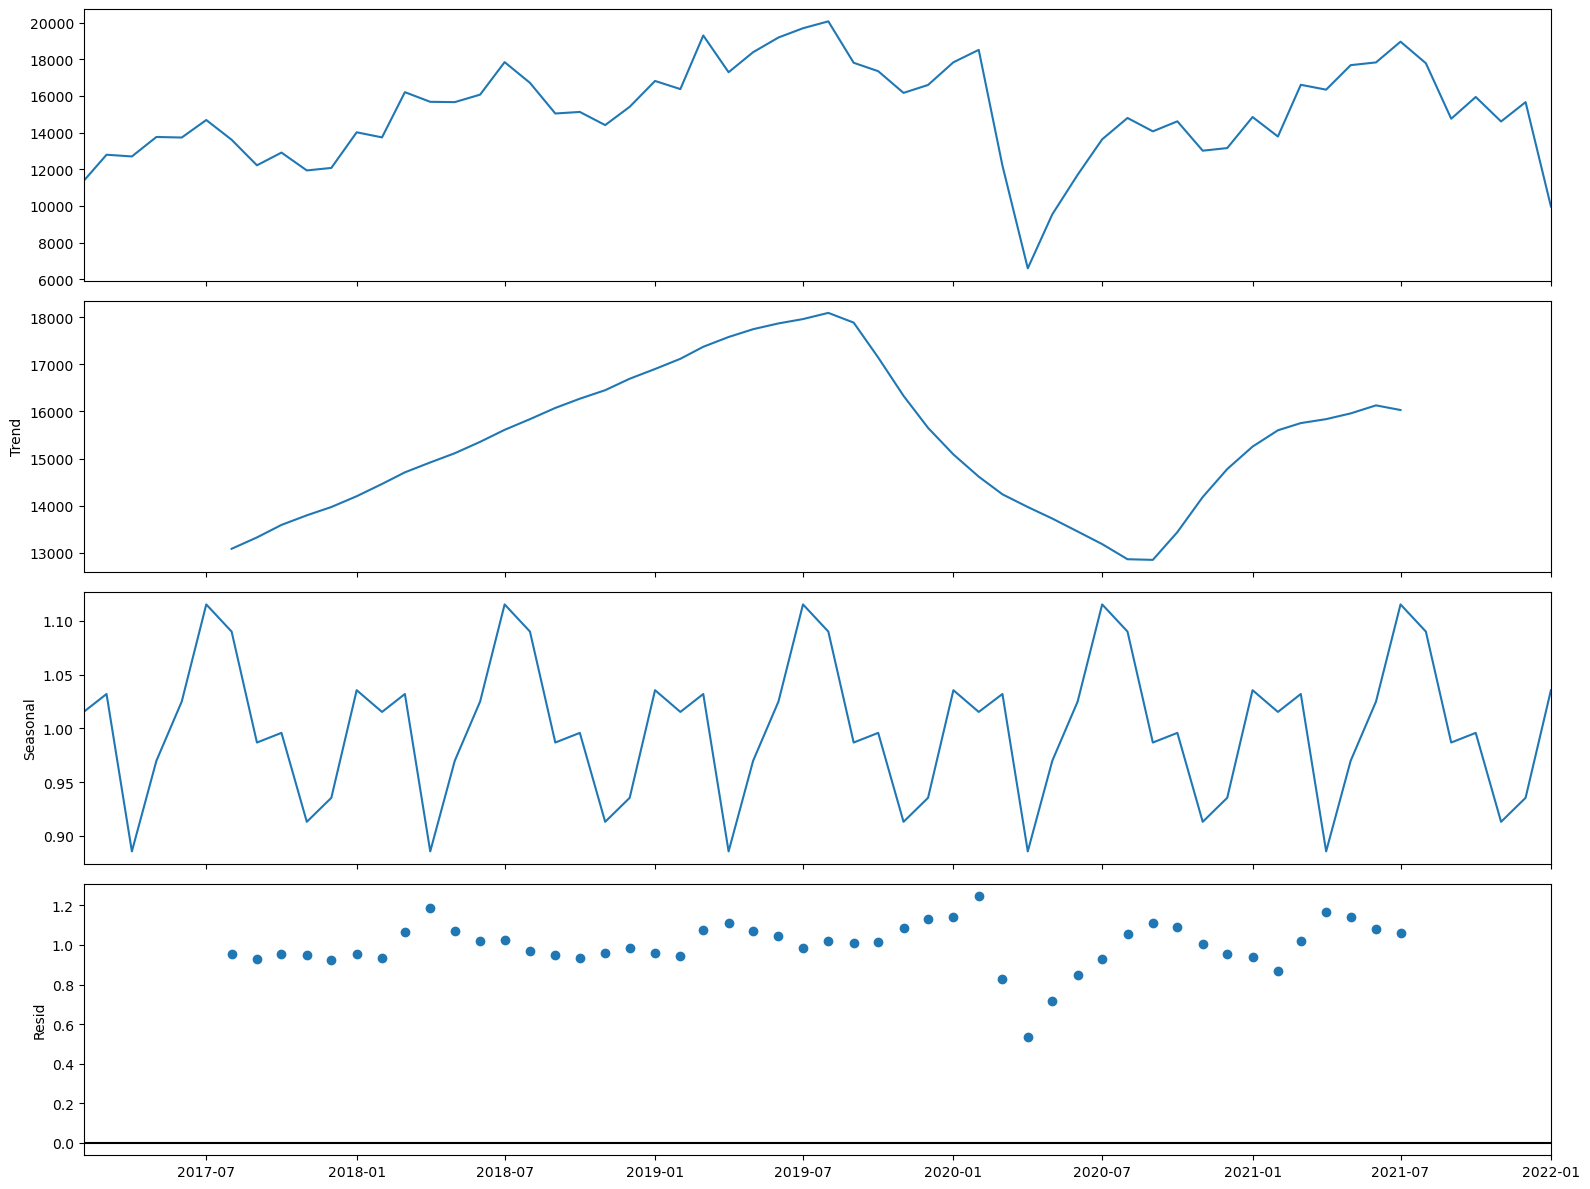

In [69]:
multiplicative_decomposition = seasonal_decompose(review_high_rated, 
                                                  model='multiplicative', period = 12)

plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot()
plt.show()

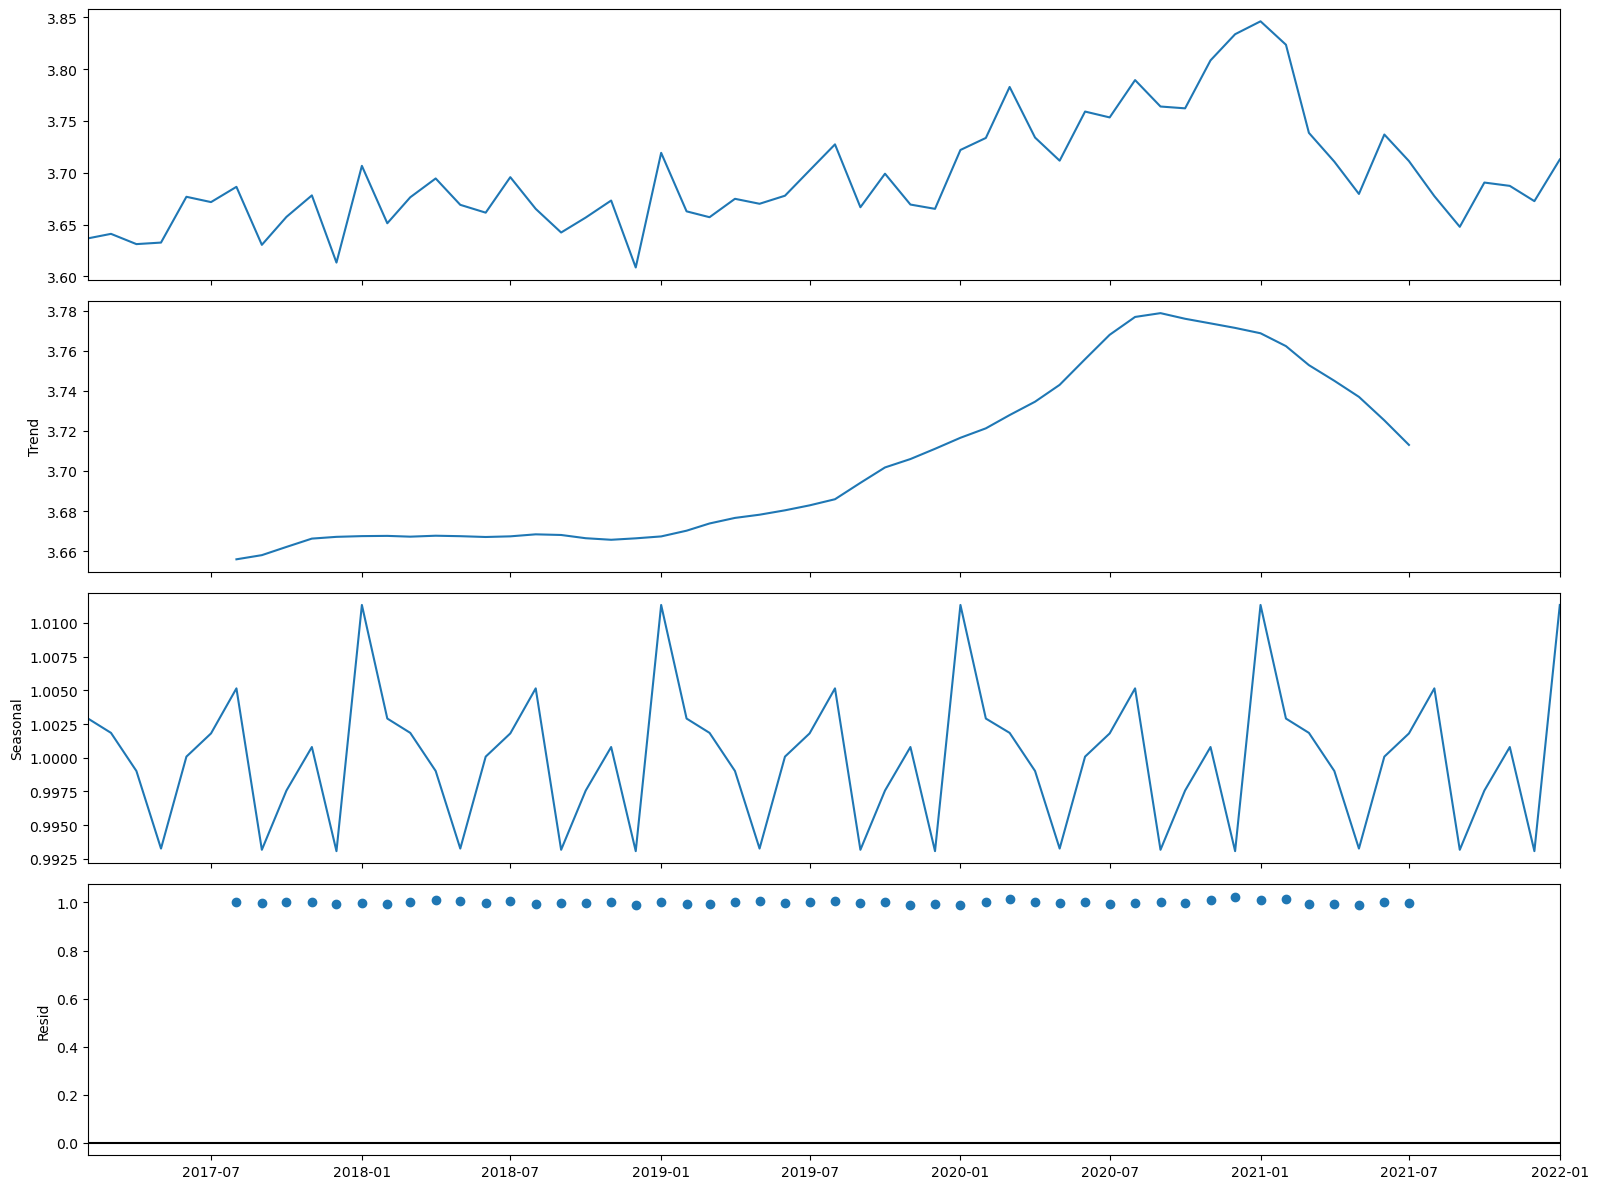

In [70]:
multiplicative_decomposition = seasonal_decompose(rating_df, 
                                                  model='multiplicative', period = 12)

plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot()
plt.show()

In [71]:
# How does the sentiment of review and tips(useful, funny, cool) correlate with the success metrics of restaurants?

query = """
WITH TargetBusinesses AS (
    -- Step 1: Establish the base restaurants and their success metrics
    SELECT business_id, stars AS avg_rating, review_count
    FROM business
    WHERE business_id IN {}
),
ReviewSentiment AS (
    -- Step 2: Sum up the sentiment votes, but ONLY for our target restaurants
    SELECT 
        business_id,
        SUM(useful) AS useful_count,
        SUM(funny) AS funny_count,
        SUM(cool) AS cool_count
    FROM review
    WHERE business_id IN {}  -- This is the crucial optimization step!
    GROUP BY business_id
)

-- Step 3: Bring them together cleanly without unnecessary outer GROUP BYs
SELECT 
    b.business_id,
    b.avg_rating,
    b.review_count,
    s.useful_count,
    s.funny_count,
    s.cool_count
FROM TargetBusinesses b
JOIN ReviewSentiment s ON b.business_id = s.business_id
ORDER BY b.review_count DESC
""".format(tuple(business_id['business_id']), tuple(business_id['business_id']))

# Execute the query
sentiment_df = pd.read_sql_query(query, conn)

sentiment_df = remove_outliers(sentiment_df, 'review_count')
sentiment_df = remove_outliers(sentiment_df, 'useful_count')
sentiment_df = remove_outliers(sentiment_df, 'funny_count')
sentiment_df = remove_outliers(sentiment_df, 'cool_count')

# Display the clean dataset ready for correlation
display(sentiment_df.head())

,business_id,avg_rating,review_count,useful_count,funny_count,cool_count
1878,k8C4zFZDl8GcjIapHCB77w,4.0,176,91,23,29
1887,17AnbEkqAiE66YFTDYFvgw,2.5,176,110,25,25
1895,ZNZcptwIHne1PDcHaMbA-A,4.0,176,81,13,29
1906,radib3GHt_Up9-zhUjM1ew,3.5,175,128,29,21
1907,CPXc2AorgYR1uxPopLC79A,3.5,175,100,11,36


In [72]:
# Success Score
sentiment_df['success_score'] = calculate_success_metric(sentiment_df)

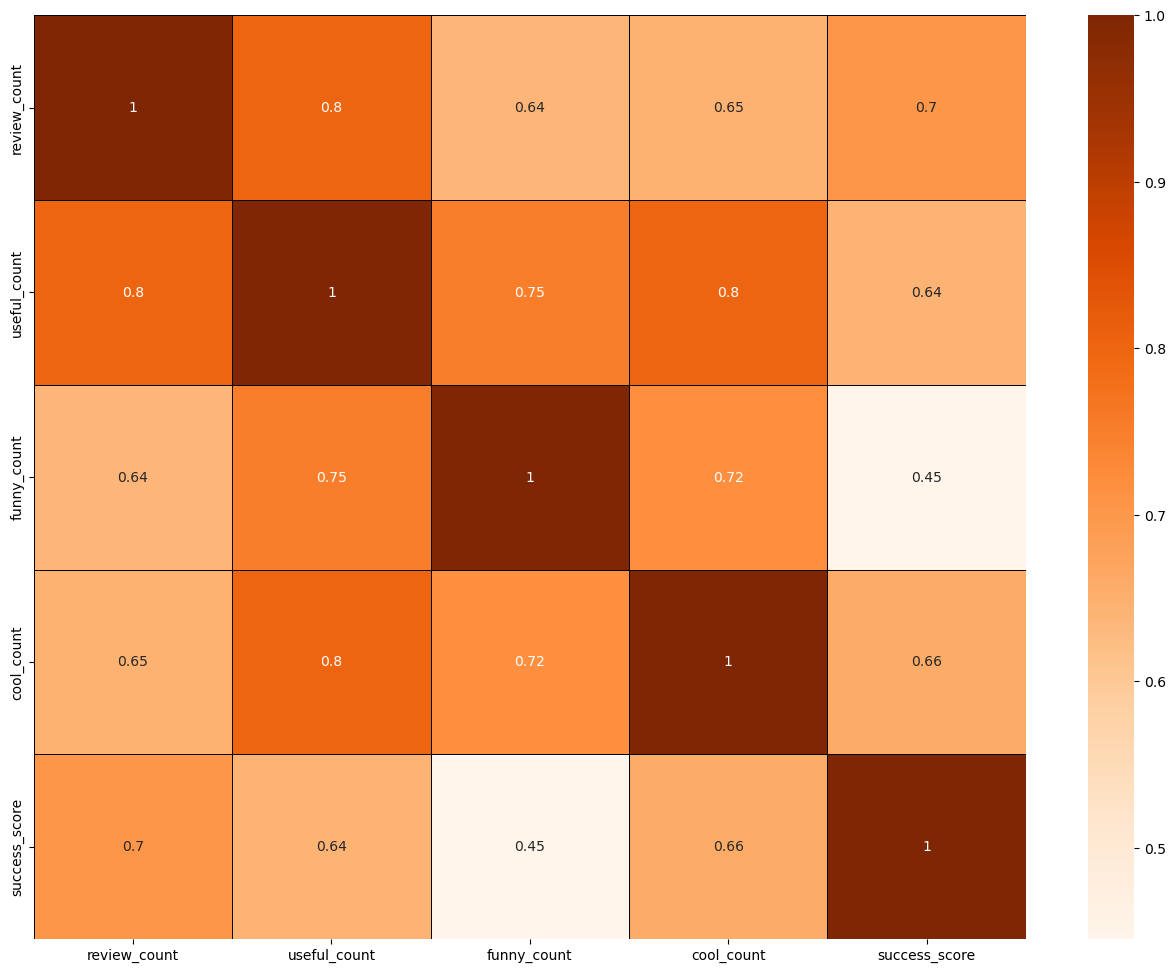

In [73]:
# Replaced custom_cmap with the built-in 'Oranges' palette
sns.heatmap(sentiment_df.iloc[:,2:].corr(), cmap='Oranges', annot=True, linewidths=0.5, linecolor='black')

plt.show()

In [74]:
# Is there any difference in engagement of elite users and non elite users?

query = """
WITH UserCategorization AS (
    -- Step 1: Label every user as Elite or Not Elite
    SELECT 
        review_count,
        CASE 
            WHEN elite = '' THEN 'Not Elite'
            ELSE 'Elite'
        END AS elite_status
    FROM user
)

-- Step 2: Aggregate the totals based on those new labels
SELECT 
    elite_status,
    COUNT(*) AS total_users,
    SUM(review_count) AS total_reviews
FROM UserCategorization
GROUP BY elite_status;
"""

elite_df = pd.read_sql_query(query, conn)
display(elite_df)

,elite_status,total_users,total_reviews
0,Elite,91198,20484441
1,Not Elite,1896699,26021235


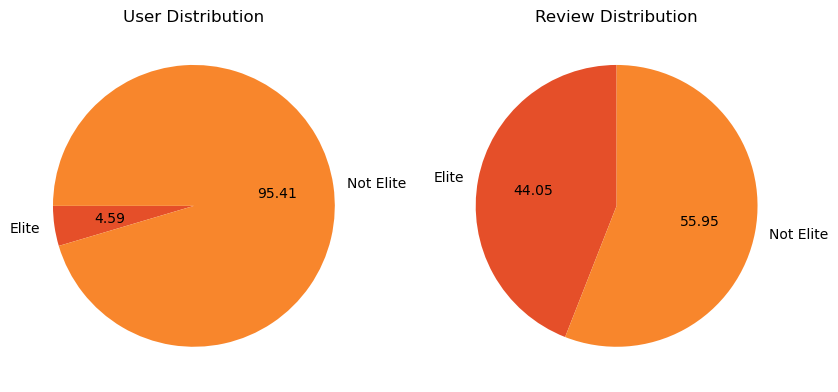

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# --- Subplot 1: User Distribution ---
plt.subplot(1,2,1)
plt.title('User Distribution')
# Using 'total_users' and 'elite_status'
plt.pie(elite_df['total_users'], labels=elite_df['elite_status'], autopct='%.2f', startangle=180, colors=['#E54F29', '#F8862C'])

# --- Subplot 2: Review Distribution ---
plt.subplot(1,2,2)
plt.title('Review Distribution')
# Using 'total_reviews' and 'elite_status'
plt.pie(elite_df['total_reviews'], labels=elite_df['elite_status'], autopct='%.2f', startangle=90, colors=['#E54F29', '#F8862C'])

plt.show()

In [ ]:
# What are the busiest hours for restaurants?

review_engagement = pd.read_sql_query("""SELECT
    cast (strftime('%H',date) as integer)
    as hour,
    COUNT(*) AS review_count
FROM
    review
GROUP BY
    hour;
""",conn)

tip_engagement = pd.read_sql_query("""SELECT
    cast (strftime('%H',date) as integer)
    as hour,
    COUNT(*) AS tip_count
FROM
    tip
GROUP BY
    hour;
""",conn)

checkin = pd.read_sql_query("""SELECT date FROM checkin""",conn)
checkin_engagement = []
for i in checkin['date']:
    checkin_engagement.extend([datetime.strptime(j.strip(),"%Y-%m-%d %H:%M:%S").strftime("%H") for j in i.split(',')])

checkin_engagement = pd.DataFrame(checkin_engagement).astype('int').groupby(0)[[0]].count()

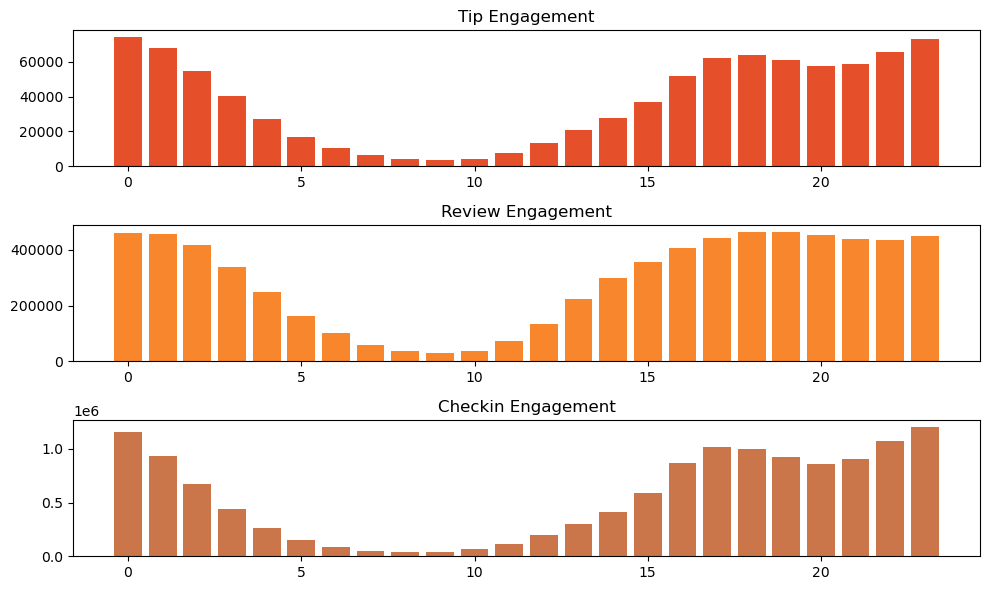

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10,6))

# --- Subplot 1: Tip Engagement ---
plt.subplot(3,1,1)
plt.title('Tip Engagement')
plt.bar(tip_engagement['hour'], tip_engagement['tip_count'], color = '#E54F29')

# --- Subplot 2: Review Engagement ---
plt.subplot(3,1,2)
plt.title('Review Engagement')
plt.bar(review_engagement['hour'], review_engagement['review_count'], color = '#F8862C')

# --- Subplot 3: Checkin Engagement ---
plt.subplot(3,1,3)
plt.title('Checkin Engagement')
plt.bar(checkin_engagement.index, checkin_engagement[0], color = '#CB754B')

plt.tight_layout()
plt.show()

Correlation Coefficient: -0.034
P-Value: 3.128e-63


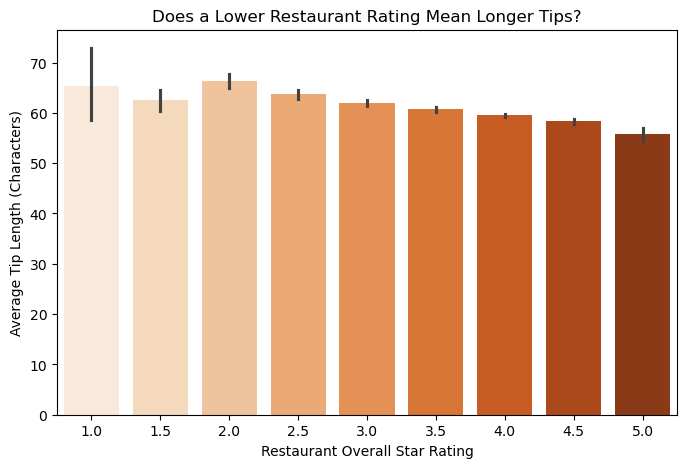

Conclusion: Statistically significant! Lower-rated restaurants receive longer tips (The 'Rant' factor is real).


In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Pull the data: Join the tip text with the business's overall star rating
query_tip_rant = f"""
WITH TipLengths AS (
    SELECT 
        b.stars,
        LENGTH(t.text) AS tip_length
    FROM tip t
    JOIN business b ON t.business_id = b.business_id
    WHERE t.business_id IN {tuple(business_id['business_id'])}
)
SELECT stars, tip_length FROM TipLengths;
"""
tip_rant_df = pd.read_sql_query(query_tip_rant, conn)

# 2. Calculate the Pearson Correlation
correlation, p_value = stats.pearsonr(tip_rant_df['stars'], tip_rant_df['tip_length'])

print(f"Correlation Coefficient: {correlation:.3f}")
print(f"P-Value: {p_value:.3e}")

# 3. Visualize it
plt.figure(figsize=(8,5))
plt.title('Does a Lower Restaurant Rating Mean Longer Tips?')
sns.barplot(x='stars', y='tip_length', data=tip_rant_df, palette='Oranges')
plt.ylabel('Average Tip Length (Characters)')
plt.xlabel('Restaurant Overall Star Rating')
plt.show()

# 4. Conclusion Logic
if p_value < 0.05 and correlation < 0:
    print("Conclusion: Statistically significant! Lower-rated restaurants receive longer tips (The 'Rant' factor is real).")
else:
    print("Conclusion: No significant proof that lower-rated restaurants receive longer tips.")

In [101]:
# The Weekend vs. Weekday Phenomenon

# 1. Pull the raw checkin dates
query_weekend = f"""
SELECT date FROM checkin WHERE business_id IN {tuple(business_id['business_id'])}
"""
checkin_df = pd.read_sql_query(query_weekend, conn)

# 2. Clean the comma-separated dates (Faster pandas method)
checkin_dates = []
for dates in checkin_df['date']:
    if pd.notna(dates):
        checkin_dates.extend([d.strip() for d in dates.split(',')])

# 3. Convert to a proper DataFrame and identify Weekends vs Weekdays
df_dates = pd.DataFrame(checkin_dates, columns=['datetime'])
df_dates['datetime'] = pd.to_datetime(df_dates['datetime'])
df_dates['date_only'] = df_dates['datetime'].dt.date
df_dates['day_of_week'] = df_dates['datetime'].dt.day_name()
df_dates['is_weekend'] = df_dates['day_of_week'].isin(['Saturday', 'Sunday'])

# 4. Count total check-ins per day
daily_checkins = df_dates.groupby(['date_only', 'is_weekend']).size().reset_index(name='checkin_count')

# 5. Split the data into two buckets
weekend_counts = daily_checkins[daily_checkins['is_weekend'] == True]['checkin_count']
weekday_counts = daily_checkins[daily_checkins['is_weekend'] == False]['checkin_count']

# 6. Run the T-Test
t_stat, p_val = stats.ttest_ind(weekend_counts, weekday_counts, equal_var=False)

print(f"Average Daily Check-ins (Weekend): {weekend_counts.mean():.1f}")
print(f"Average Daily Check-ins (Weekday): {weekday_counts.mean():.1f}")
print(f"P-Value: {p_val:.3e}")

if p_val < 0.05 and weekend_counts.mean() > weekday_counts.mean():
    print("\nConclusion: Weekends drive significantly higher foot traffic than weekdays.")
else:
    print("\nConclusion: Foot traffic is evenly spread. Weekends are not significantly busier.")

Average Daily Check-ins (Weekend): 946.1
Average Daily Check-ins (Weekday): 611.7
P-Value: 2.271e-153

Conclusion: Weekends drive significantly higher foot traffic than weekdays.


Avg 'Useful' Votes per Review (Elite): 2.24
Avg 'Useful' Votes per Review (Non-Elite): 0.63
P-Value: 0.000e+00


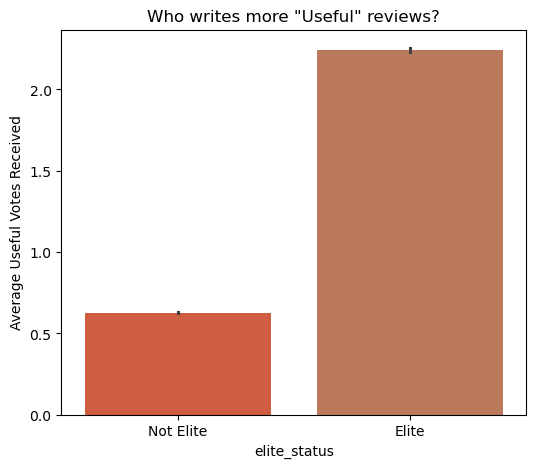

Conclusion: Elite users are highly influential. Their reviews are voted 'Useful' significantly more often.


In [104]:
# The "Elite" Influence

# 1. Pull Elite Status and their Useful votes
query_elite = f"""
SELECT 
    CASE WHEN u.elite = '' THEN 'Not Elite' ELSE 'Elite' END AS elite_status,
    r.useful
FROM review r
JOIN user u ON r.user_id = u.user_id
WHERE r.business_id IN {tuple(business_id['business_id'])}
"""
elite_influence_df = pd.read_sql_query(query_elite, conn)

# 2. Split the groups
elite_useful = elite_influence_df[elite_influence_df['elite_status'] == 'Elite']['useful']
non_elite_useful = elite_influence_df[elite_influence_df['elite_status'] == 'Not Elite']['useful']

# 3. Run the T-Test
t_stat_elite, p_val_elite = stats.ttest_ind(elite_useful, non_elite_useful, equal_var=False)

print(f"Avg 'Useful' Votes per Review (Elite): {elite_useful.mean():.2f}")
print(f"Avg 'Useful' Votes per Review (Non-Elite): {non_elite_useful.mean():.2f}")
print(f"P-Value: {p_val_elite:.3e}")

# 4. Visualize it
plt.figure(figsize=(6,5))
plt.title('Who writes more "Useful" reviews?')
sns.barplot(x='elite_status', y='useful', data=elite_influence_df, palette=['#E54F29', '#CB754B'])
plt.ylabel('Average Useful Votes Received')
plt.show()

if p_val_elite < 0.05 and elite_useful.mean() > non_elite_useful.mean():
    print("Conclusion: Elite users are highly influential. Their reviews are voted 'Useful' significantly more often.")
else:
    print("Conclusion: Elite status does not guarantee a more 'Useful' review.")